In [ ]:
# ---------------------------------------------------------
# Import required libraries
# - Data handling: pandas, numpy
# - Plotting: matplotlib
# - Utilities: time, random
# - Machine learning: sklearn
# ---------------------------------------------------------
import time
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# ---------------------------------------------------------
# Load training and testing datasets
# ---------------------------------------------------------
def load_data():
  drive.mount('/content/drive')

  train_path = 'data/UNSW_NB15_training-set.csv'
  test_path = 'data/UNSW_NB15_testing-set.csv'

  train_df = pd.read_csv(train_path)
  test_df = pd.read_csv(test_path)

  return train_df, test_df

In [ ]:
# ---------------------------------------------------------
# Clean dataset by removing irrelevant or leakage-prone
# columns, checking data quality, and removing duplicates
# ---------------------------------------------------------
def clean_data(train_df, test_df):
  # Work on copies to prevent modifying original datasets
  train_df = train_df.copy()
  test_df = test_df.copy()

  # Remove column id (not useful for prediction)
  if 'id' in train_df.columns:
      train_df = train_df.drop(columns=['id'])
      print("Column 'id' successfully dropped from Training Set.")
  else:
      print("Column 'id' already removed from Training Set.")

  if 'id' in test_df.columns:
      test_df = test_df.drop(columns=['id'])
      print("Column 'id' successfully dropped from Testing Set.")
  else:
      print("Column 'id' already removed from Testing Set.")

  # Remove column source ip address (no generalisation & meaningless numerically)
  if 'srcip' in train_df.columns:
      train_df = train_df.drop(columns=['srcip'])
      print("Column 'srcip' successfully dropped from Training Set.")
  else:
      print("Column 'srcip' already removed from Training Set.")

  if 'srcip' in test_df.columns:
      test_df = test_df.drop(columns=['srcip'])
      print("Column 'srcip' successfully dropped from Testing Set.")
  else:
      print("Column 'srcip' already removed from Testing Set.")

  # Remove start time (Data might be collected at specific times) (temporal bias)
  if 'stime' in train_df.columns:
      train_df = train_df.drop(columns=['stime'])
      print("Column 'stime' successfully dropped from Training Set.")
  else:
      print("Column 'stime' already removed from Training Set.")

  if 'stime' in test_df.columns:
      test_df = test_df.drop(columns=['stime'])
      print("Column 'stime' successfully dropped from Testing Set.")
  else:
      print("Column 'stime' already removed from Testing Set.")

  # Remove last time (same reason as start time)
  if 'ltime' in train_df.columns:
      train_df = train_df.drop(columns=['ltime'])
      print("Column 'ltime' successfully dropped from Training Set.")
  else:
      print("Column 'ltime' already removed from Training Set.")

  if 'ltime' in test_df.columns:
      test_df = test_df.drop(columns=['ltime'])
      print("Column 'ltime' successfully dropped from Testing Set.")
  else:
      print("Column 'ltime' already removed from Testing Set.")


  # Remove column attack category as it directly reveals an attack (leakage)
  if 'attack_cat' in train_df.columns:
      train_df = train_df.drop(columns=['attack_cat'])
      print("Column 'attack_cat' successfully dropped from Training Set.")
  else:
      print("Column 'attack_cat' already removed from Training Set.")

  if 'attack_cat' in test_df.columns:
      test_df = test_df.drop(columns=['attack_cat'])
      print("Column 'attack_cat' successfully dropped from Testing Set.")
  else:
      print("Column 'attack_cat' already removed from Testing Set.")

  # Check for missing values in both datasets
  print("Missing values in Training Set:", train_df.isnull().sum().sum())
  print("Missing values in Testing Set:", test_df.isnull().sum().sum())

  # Check for duplicate rows in both datasets
  print("\nDuplicate rows in Training Set:", train_df.duplicated().sum())
  print("Duplicate rows in Testing Set:", test_df.duplicated().sum())

  # Remove duplicates
  train_df.drop_duplicates(inplace=True)
  test_df.drop_duplicates(inplace=True)

  return train_df, test_df

In [ ]:
# ---------------------------------------------------------
# Encode categorical features using Label Encoding
# Converts string categories into numeric values for model input
# ---------------------------------------------------------
def encode_data(train_df, test_df):
    # List of categorical columns in the dataset
    cat_cols = ['proto', 'service', 'state']

    for col in cat_cols:
        le = LabelEncoder()
        # Convert to string to ensure consistency
        train_df[col] = train_df[col].astype(str)

        # Fit encoder only on training data to avoid data leakage
        le.fit(train_df[col])

        # Transform training data
        train_df[col] = le.transform(train_df[col])

        # Transform test data
        # Handle unseen labels in test set by mapping to a new index
        test_df[col] = test_df[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in le.classes_ else len(le.classes_)
        )
    return train_df, test_df

In [ ]:
# ---------------------------------------------------------
# Split dataset into training and validation sets (80-20)
# Stratified split ensures class distribution is preserved
# ---------------------------------------------------------
def split_train_val(train_df):
    X = train_df.drop(columns=['label'])
    y = train_df['label']

    # Perform stratified split to maintain class balance
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return X_train, y_train, X_val, y_val



In [ ]:
# ---------------------------------------------------------
# Wrapper class for Random Forest model
# Used to evaluate model performance for metaheuristic search
# Includes feature selection + hyperparameter tuning
# ---------------------------------------------------------
class RFModel:
    def __init__(self, X_train, y_train, X_val, y_val):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val

        # Total number of features
        self.n_features = X_train.shape[1]

        # Cache to store evaluated configurations (for efficiency)
        self.cache = {}

    def evaluate(self, params, feature_mask=None):
        # If no feature mask is provided, use all features
        if feature_mask is None:
            feature_mask = np.ones(self.n_features, dtype=bool)

        # Ensure at least one feature is selected (avoid invalid model)
        if feature_mask.sum() == 0:
            feature_mask[np.random.randint(self.n_features)] = True

        # Create a unique key for caching results
        key = (tuple(sorted(params.items())), tuple(feature_mask))
        if key in self.cache:
            return self.cache[key]

        # Select features based on mask
        selected_cols = self.X_train.columns[feature_mask]

        # Initialize Random Forest model
        model = RandomForestClassifier(
            **params,
            class_weight="balanced",  # handle class imbalance
            random_state=42,
            n_jobs=-1
        )

        # Train model on selected features
        model.fit(self.X_train[selected_cols], self.y_train)

        # Predict on validation set
        y_pred = model.predict(self.X_val[selected_cols])

        # Keep F1 as the main goal, but add a small penalty for using too many features
        f1 = f1_score(self.y_val, y_pred)
        feature_ratio = feature_mask.sum() / self.n_features
        score = f1 - 0.02 * feature_ratio

        # Store result in cache to avoid recomputation
        self.cache[key] = score
        return score

In [ ]:
class SimulatedAnnealing:
    def __init__(self, model, max_iters=100, initial_temp=10.0, alpha=0.95, min_feature_ratio=0.3):
        # Model wrapper used for evaluation
        self.model = model
        # Number of iterations for the search process
        self.max_iters = max_iters
        # Initial temperature (controls exploration)
        self.initial_temp = initial_temp
        # Cooling rate (temperature decay factor)
        self.alpha = alpha
        # Minimum proportion of features to keep
        self.min_feature_ratio = min_feature_ratio

        # Search space for Random Forest hyperparameters
        self.param_space = {
            "n_estimators": [100, 200, 300, 400],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2"]
        }

    # Ensure feature mask is valid and not too small
    def _enforce_mask_constraints(self, mask):
        if mask.sum() == 0:
            mask[np.random.randint(len(mask))] = True

        # Enforce minimum number of selected features
        min_features = int(len(mask) * self.min_feature_ratio)
        if mask.sum() < min_features:
            off_idx = np.where(mask == False)[0]
            needed = min_features - mask.sum()
            mask[np.random.choice(off_idx, needed, replace=False)] = True

        return mask

    # Generate a neighboring solution by modifying parameters or features
    def random_neighbor(self, current_params, current_mask):
        neighbor_params = current_params.copy()
        neighbor_mask = current_mask.copy()

        # With higher probabilities, tweak hyperparameters
        if np.random.rand() < 0.7:
            p = np.random.choice(list(self.param_space.keys()))
            neighbor_params[p] = np.random.choice(self.param_space[p])
        else:
            # Otherwise, flip one feature (feature selection)
            idx = np.random.randint(len(neighbor_mask))
            neighbor_mask[idx] = not neighbor_mask[idx]

        # Ensure valid feature selection
        neighbor_mask = self._enforce_mask_constraints(neighbor_mask)
        return neighbor_params, neighbor_mask

    # Main Simulated Annealing optimization process
    def run(self):
        start_time = time.time()

        # Initialize random solution
        current_params = {k: np.random.choice(v) for k, v in self.param_space.items()}
        current_mask = np.random.choice([True, False], size=self.model.n_features)
        current_mask = self._enforce_mask_constraints(current_mask)

        # Evaluate initial solution
        current_score = self.model.evaluate(current_params, current_mask)

        # Track best solution found
        best_params = current_params.copy()
        best_mask = current_mask.copy()
        best_score = current_score

        # Initialize temperature
        temperature = self.initial_temp

        # Iterative optimization loop
        for i in range(self.max_iters):
            neighbor_params, neighbor_mask = self.random_neighbor(current_params, current_mask)
            neighbor_score = self.model.evaluate(neighbor_params, neighbor_mask)

            # Compute change in objective
            delta = neighbor_score - current_score

            # Accept better solutions or accept worse solution with probability
            if delta > 0 or np.random.rand() < np.exp(delta / temperature):
                current_params = neighbor_params
                current_mask = neighbor_mask
                current_score = neighbor_score

                # Update best solution
                if neighbor_score > best_score:
                    best_score = neighbor_score
                    best_params = neighbor_params
                    best_mask = neighbor_mask

            # Gradually reduce temperature (cooling schedule)
            temperature *= self.alpha

        runtime = time.time() - start_time

        # Print summary of results
        print(f"Runtime: {runtime:.2f} seconds")
        print(f"Best F1 Score found by SA: {best_score:.4f}")
        print(f"Best Parameters: {best_params}")
        print(f"Number of Selected Features: {np.sum(best_mask)}")

        return best_params, best_mask, runtime

In [ ]:
class TabuSearch:
    def __init__(self, model, max_iters=40, tabu_size=15, neighbors_to_sample=8, min_feature_ratio=0.2):
        # Model wrapper used for evaluation
        self.model = model

        # Number of iterations
        self.max_iters = max_iters

        # Maximum size of tabu list (memory of visited solutions)
        self.tabu_size = tabu_size

        # Number of neighbors to explore per iteration
        self.neighbors_to_sample = neighbors_to_sample

        # Minimum proportion of features to retain
        self.min_feature_ratio = min_feature_ratio

        # Tabu list to store recently visited solutions
        self.tabu_list = []

        # Search space for Random Forest hyperparameters
        self.param_space = {
            "n_estimators": [100, 200, 300, 400],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2"]
        }

    # Ensure feature mask is valid and satisfies minimum size
    def _enforce_mask_constraints(self, mask):
        # Prevent zero-feature selection
        if mask.sum() == 0:
            mask[np.random.randint(len(mask))] = True

        # Ensure minimum number of features is selected
        min_features = int(len(mask) * self.min_feature_ratio)
        if mask.sum() < min_features:
            off_idx = np.where(mask == False)[0]
            needed = min_features - mask.sum()
            mask[np.random.choice(off_idx, needed, replace=False)] = True

        return mask

    # Generate a list of neighboring solutions
    def get_neighbors(self, current_params, current_mask):
        neighbors = []

        for _ in range(self.neighbors_to_sample):
            # Copy current solution
            n_params, n_mask = current_params.copy(), current_mask.copy()

            # With higher probability, modify hyperparameters
            if np.random.rand() < 0.6:
                p = np.random.choice(list(self.param_space.keys()))
                n_params[p] = np.random.choice(self.param_space[p])
            else:
                # Otherwise, flip one feature (feature selection)
                idx = np.random.randint(len(n_mask))
                n_mask[idx] = not n_mask[idx]

            # Ensure valid feature mask
            neighbors.append((n_params, self._enforce_mask_constraints(n_mask)))

        return neighbors

    # Main Tabu Search optimization loop
    def run(self):
        start_time = time.time()

        # Initialize random solution
        curr_p = {k: np.random.choice(v) for k, v in self.param_space.items()}
        curr_m = self._enforce_mask_constraints(
            np.random.choice([True, False], size=self.model.n_features)
        )

        # Evaluate initial solution
        best_score = self.model.evaluate(curr_p, curr_m)
        best_p, best_m = curr_p.copy(), curr_m.copy()

        # Iterative search process
        for i in range(self.max_iters):
            # Generate candidate neighbors
            neighbors = self.get_neighbors(curr_p, curr_m)

            best_neighbor_score = -float('inf')
            best_neighbor_node = None

            # Evaluate all neighbors
            for n_p, n_m in neighbors:
                # Signature used to identify solution in tabu list
                sig = (tuple(sorted(n_p.items())), tuple(n_m))

                score = self.model.evaluate(n_p, n_m)

                # ASPIRATION CRITERIA:
                # Allow tabu solution if it improves global best
                if sig not in self.tabu_list or score > best_score:
                    if score > best_neighbor_score:
                        best_neighbor_score = score
                        best_neighbor_node = (n_p, n_m, sig)

            # Move to best neighbor found
            if best_neighbor_node:
                curr_p, curr_m, sig = best_neighbor_node

                # Add solution to tabu list
                self.tabu_list.append(sig)

                # Maintain tabu list size
                if len(self.tabu_list) > self.tabu_size:
                    self.tabu_list.pop(0)

                # Update global best solution
                if best_neighbor_score > best_score:
                    best_score, best_p, best_m = best_neighbor_score, curr_p.copy(), curr_m.copy()

            # Print progress
            print(f"Tabu Iter {i+1}: Global Best: {best_score:.4f}")

        runtime = time.time() - start_time

        return best_p, best_m, runtime

In [ ]:
# ---------------------------------------------------------
# Genetic Algorithm for hyperparameter tuning and feature selection
# Uses population-based search with selection, crossover, and mutation
# ---------------------------------------------------------
class GeneticAlgorithm:
    def __init__(self, model, generations=20, pop_size=15, mutation_rate=0.1, min_feature_ratio=0.2):
        # Model wrapper used to evaluate candidate solutions
        self.model = model

        # Number of generations to evolve
        self.generations = generations

        # Number of individuals in each population
        self.pop_size = pop_size

        # Probability of mutation
        self.mutation_rate = mutation_rate

        # Minimum proportion of features to retain
        self.min_feature_ratio = min_feature_ratio

        # Search space for Random Forest hyperparameters
        self.param_space = {
            "n_estimators": [100, 200, 300, 400],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2"]
        }

    # Ensure feature mask is valid and not too small
    def _enforce_mask_constraints(self, mask):
        # Prevent zero-feature selection
        if mask.sum() == 0:
            mask[np.random.randint(len(mask))] = True

        # Enforce minimum number of selected features
        min_features = int(len(mask) * self.min_feature_ratio)
        if mask.sum() < min_features:
            off_idx = np.where(mask == False)[0]
            needed = min_features - mask.sum()
            mask[np.random.choice(off_idx, needed, replace=False)] = True

        return mask

    # Create a random individual consisting of hyperparameters + feature mask
    def _create_individual(self):
        params = {k: np.random.choice(v) for k, v in self.param_space.items()}
        mask = np.random.choice([True, False], size=self.model.n_features)
        mask = self._enforce_mask_constraints(mask)
        return [params, mask]

    # Main Genetic Algorithm optimization loop
    def run(self):
        start_time = time.time()

        # Initialize random population
        population = [self._create_individual() for _ in range(self.pop_size)]

        # Track best solution found so far
        best_score = -1
        best_params, best_mask = None, None

        # Track generations without improvement
        no_improvement = 0

        for gen in range(self.generations):
            # Evaluate all individuals in current population
            scores = [self.model.evaluate(p, m) for p, m in population]

            # Update global best solution
            current_gen_best_idx = np.argmax(scores)
            if scores[current_gen_best_idx] > best_score:
                best_score = scores[current_gen_best_idx]
                best_params = population[current_gen_best_idx][0].copy()
                best_mask = population[current_gen_best_idx][1].copy()
                no_improvement = 0
            else:
                no_improvement += 1

            # Elitism: preserve the best two individuals automatically
            sorted_idx = np.argsort(scores)[::-1]
            elites = [population[i] for i in sorted_idx[:2]]

            # Select top half of population as parents
            parents = [population[i] for i in sorted_idx[:self.pop_size // 2]]

            # Start next generation with elites
            new_population = elites

            while len(new_population) < self.pop_size:
                # Randomly choose two parents
                p1, p2 = random.sample(parents, 2)

                # Uniform crossover:
                # each hyperparameter/feature is inherited from either parent
                child_params = {
                    k: random.choice([p1[0][k], p2[0][k]])
                    for k in self.param_space.keys()
                }
                child_mask = np.array([
                    random.choice([p1[1][i], p2[1][i]])
                    for i in range(len(p1[1]))
                ])

                # Adaptive mutation:
                # increase mutation rate if search is stagnating
                current_mutation = self.mutation_rate if no_improvement < 3 else self.mutation_rate * 2

                if random.random() < current_mutation:
                    if random.random() < 0.5:
                        # Mutate feature mask by flipping one feature
                        idx = random.randint(0, len(child_mask) - 1)
                        child_mask[idx] = not child_mask[idx]
                    else:
                        # Mutate one hyperparameter
                        p = random.choice(list(self.param_space.keys()))
                        child_params[p] = random.choice(self.param_space[p])

                # Ensure valid feature mask
                child_mask = self._enforce_mask_constraints(child_mask)

                # Add child to new population
                new_population.append([child_params, child_mask])

            # Replace old population with new generation
            population = new_population

            # Print progress
            print(f"GA Gen {gen+1}: Best Score: {best_score:.4f}")

            # Stop early if no improvement for several generations
            if no_improvement > 5:
                break

        runtime = time.time() - start_time
        return best_params, best_mask, runtime

In [ ]:
# ---------------------------------------------------------
# Final evaluation of all models using CV + test set
# ---------------------------------------------------------
def final_evaluate(X_train_full, y_train_full, X_test, y_test, best_params_dict, feature_masks_dict, k=5):
    # Dictionary to store results for each method
    results_dict = {}

    # Loop through each method (Baseline, SA, GA, Tabu)
    for heuristic_name, params in best_params_dict.items():
        print(f"\nEvaluating {heuristic_name} model...")

        # Get selected feature mask for this method
        mask = feature_masks_dict[heuristic_name]

        # Initialize Random Forest with given parameters
        model = RandomForestClassifier(
            **params,
            class_weight='balanced',  # Handle class imbalance
            random_state=42,
            n_jobs=-1
        )

        # Extract selected feature columns using mask
        selected_cols = X_train_full.columns[mask]

        # -------------------------------
        # Cross-validation (robust evaluation)
        # -------------------------------
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

        # Compute F1 score across k folds
        cv_scores = cross_val_score(
            model,
            X_train_full[selected_cols],
            y_train_full,
            cv=skf,
            scoring='f1'
        )

        # -------------------------------
        # Train on full training data
        # -------------------------------
        model.fit(X_train_full[selected_cols], y_train_full)

        # Predict on unseen test data
        y_pred = model.predict(X_test[selected_cols])

        # -------------------------------
        # Compute evaluation metrics
        # -------------------------------
        f1 = f1_score(y_test, y_pred)           # F1 score (main metric)
        acc = accuracy_score(y_test, y_pred)    # Accuracy

        # Confusion matrix: TN, FP, FN, TP
        cm = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        # Derived metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        # Detailed classification report (precision, recall, F1 per class)
        report = classification_report(
            y_test,
            y_pred,
            target_names=['Normal', 'Attack']
        )

        # -------------------------------
        # Store all results
        # -------------------------------
        results_dict[heuristic_name] = {
            "cv_f1_mean": np.mean(cv_scores),           # Average CV F1
            "cv_f1_std": np.std(cv_scores),             # CV variability
            "test_f1": f1,                              # Test F1
            "test_accuracy": acc,                       # Test accuracy
            "precision": precision,
            "recall": recall,
            "false_positives": fp,
            "false_positive_rate": fpr,
            "selected_features_count": np.sum(mask),    # Feature reduction info
            "classification_report": report,
            "confusion_matrix": cm
        }

    return results_dict

In [ ]:
# ---------------------------------------------------------
# Utility function to print selected feature names
# ---------------------------------------------------------
def print_feature_names(mask, train_df):
    # Get all feature names (exclude label column)
    features = train_df.drop(columns=['label']).columns

    # Apply mask to select chosen features
    selected = features[mask]

    # Print number of selected features and their names
    print(f"Selected Features ({len(selected)}): {list(selected)}")

In [ ]:
# ---------------------------------------------------------
# Function to generate and print summary table of results
# ---------------------------------------------------------
def print_summary_table(results_dict, runtime_dict):
    # List to store summary data for all methods
    summary_data = []

    # Loop through each method (Baseline, SA, GA, Tabu)
    for method, metrics in results_dict.items():
        # Get runtime for the method
        runtime = runtime_dict.get(method, "N/A")

        # Append key evaluation metrics into summary table
        summary_data.append({
            "Method": method,

            # Cross-validation performance (mean and variability)
            "CV F1 Mean": round(metrics["cv_f1_mean"], 4) if not pd.isna(metrics["cv_f1_mean"]) else "N/A",
            "CV F1 Std": round(metrics["cv_f1_std"], 4) if not pd.isna(metrics["cv_f1_std"]) else "N/A",

            # Test performance (real-world performance)
            "Test F1": round(metrics["test_f1"], 4),
            "Accuracy": round(metrics["test_accuracy"], 4),

            # Classification metrics
            "Precision": round(metrics["precision"], 4),
            "Recall": round(metrics["recall"], 4),

            # False positive analysis (important in intrusion detection)
            "FPR": round(metrics["false_positive_rate"], 4),
            "False Positives": metrics["false_positives"],

            # Feature selection result
            "Selected Features": metrics["selected_features_count"],

            # Runtime for efficiency comparison
            "Runtime (s)": round(runtime, 2) if runtime != "N/A" else "N/A"
        })
    summary_df = pd.DataFrame(summary_data)

    print("\n========== FINAL SUMMARY TABLE ==========")
    print(summary_df.to_string(index=False))

    return summary_df

In [ ]:
# ---------------------------------------------------------
# Function to plot confusion matrices for all models
# ---------------------------------------------------------
def plot_all_confusion_matrices(results_dict):
    """
    Takes the results dictionary and plots a 2x2 grid of confusion matrices.
    """

    # Create a 2x2 grid of subplots (for 4 models)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Flatten axes array for easier iteration
    axes = axes.flatten()

    # Loop through each model and its evaluation metrics
    for idx, (method, metrics) in enumerate(results_dict.items()):
        # Retrieve confusion matrix
        cm = metrics.get("confusion_matrix")

        if cm is not None:
            # Plot confusion matrix using heatmap
            sns.heatmap(
                cm,
                annot=True,              # Show numbers inside cells
                fmt='d',                 # Integer format
                cmap='Blues',            # Color scheme
                ax=axes[idx],
                xticklabels=['Normal', 'Attack'],  # Predicted labels
                yticklabels=['Normal', 'Attack'],  # Actual labels
                annot_kws={"size": 14}   # Increase text size
            )

            # Set plot title and axis labels
            axes[idx].set_title(f'{method}\nConfusion Matrix', fontsize=14, fontweight='bold')
            axes[idx].set_ylabel('Actual', fontsize=12)
            axes[idx].set_xlabel('Predicted', fontsize=12)

    # Adjust layout to prevent overlapping
    plt.tight_layout()

    # Display all plots
    plt.show()

In [ ]:
# ---------------------------------------------------------
# Function to check class distribution (imbalance analysis)
# ---------------------------------------------------------
def check_class_distribution(train_df, test_df):
    print("\n========== CLASS DISTRIBUTION ==========")

    # Print number of samples in each class (training set)
    print("\nTraining set label counts:")
    print(train_df['label'].value_counts())

    # Print proportion (percentage) of each class (training set)
    print("\nTraining set label proportions:")
    print(train_df['label'].value_counts(normalize=True).round(4))

    # Print number of samples in each class (testing set)
    print("\nTesting set label counts:")
    print(test_df['label'].value_counts())

    # Print proportion (percentage) of each class (testing set)
    print("\nTesting set label proportions:")
    print(test_df['label'].value_counts(normalize=True).round(4))

In [ ]:
# ---------------------------------------------------------
# Function to compare model performance (F1 vs Accuracy)
# ---------------------------------------------------------
def plot_performance_comparison(results_dict):
    """Generates a grouped bar chart comparing F1 Score and Accuracy."""

    # Extract method names
    methods = list(results_dict.keys())

    # Extract evaluation metrics
    f1_scores = [results_dict[m]["test_f1"] for m in methods]
    accuracies = [results_dict[m]["test_accuracy"] for m in methods]

    # X-axis positions
    x = np.arange(len(methods))
    width = 0.35  # Width of each bar

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot F1 and Accuracy side by side
    rects1 = ax.bar(x - width/2, f1_scores, width, label='Test F1 Score', color='skyblue')
    rects2 = ax.bar(x + width/2, accuracies, width, label='Test Accuracy', color='salmon')

    # Labels and title
    ax.set_ylabel('Scores', fontsize=12)
    ax.set_title('Performance Comparison Across Optimization Methods', fontsize=14, fontweight='bold')

    # X-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(methods, fontsize=11)

    # Legend
    ax.legend(loc='lower right')

    # Set y-axis range slightly above 1 for better visualization
    ax.set_ylim(0, 1.1)

    # Add values on top of bars
    ax.bar_label(rects1, padding=3, fmt='%.3f')
    ax.bar_label(rects2, padding=3, fmt='%.3f')

    # Adjust layout
    plt.tight_layout()

    # Save figure for report
    plt.savefig('performance_comparison.png', dpi=300)

    # Show plot
    plt.show()

In [ ]:
# ---------------------------------------------------------
# Function to analyze trade-off: features vs performance
# ---------------------------------------------------------
def plot_tradeoff_analysis(results_dict):
    """Generates a scatter plot showing Number of Features vs F1 Score."""

    # Extract method names
    methods = list(results_dict.keys())

    # Extract feature counts and F1 scores
    features = [results_dict[m]["selected_features_count"] for m in methods]
    f1_scores = [results_dict[m]["test_f1"] for m in methods]

    # Assign colors for each method
    colors = ['gray', 'orange', 'green', 'purple']

    # Create scatter plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot each method as a point
    for i, method in enumerate(methods):
        ax.scatter(
            features[i],           # X-axis: number of features
            f1_scores[i],          # Y-axis: F1 score
            s=150,                 # Marker size
            c=colors[i],           # Color
            label=method,
            edgecolors='black',    # Outline
            zorder=5
        )

    # Labels and title
    ax.set_title('Trade-off: Feature Reduction vs. F1 Score', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Selected Features', fontsize=12)
    ax.set_ylabel('Test F1 Score', fontsize=12)

    # Grid for better readability
    ax.grid(True, linestyle='--', alpha=0.7)

    # Legend
    ax.legend(title="Algorithms", fontsize=10)

    # Adjust layout
    plt.tight_layout()

    # Save figure for report
    plt.savefig('tradeoff_analysis.png', dpi=300)

    # Show plot
    plt.show()

Mounted at /content/drive
Column 'id' successfully dropped from Training Set.
Column 'id' successfully dropped from Testing Set.
Column 'srcip' already removed from Training Set.
Column 'srcip' already removed from Testing Set.
Column 'stime' already removed from Training Set.
Column 'stime' already removed from Testing Set.
Column 'ltime' already removed from Training Set.
Column 'ltime' already removed from Testing Set.
Column 'attack_cat' successfully dropped from Training Set.
Column 'attack_cat' successfully dropped from Testing Set.
Missing values in Training Set: 0
Missing values in Testing Set: 0

Duplicate rows in Training Set: 74072
Duplicate rows in Testing Set: 28380

========== CLASS DISTRIBUTION ==========

Training set label counts:
label
0    51890
1    49379
Name: count, dtype: int64

Training set label proportions:
label
0    0.5124
1    0.4876
Name: proportion, dtype: float64

Testing set label counts:
label
0    34206
1    19746
Name: count, dtype: int64

Testing se

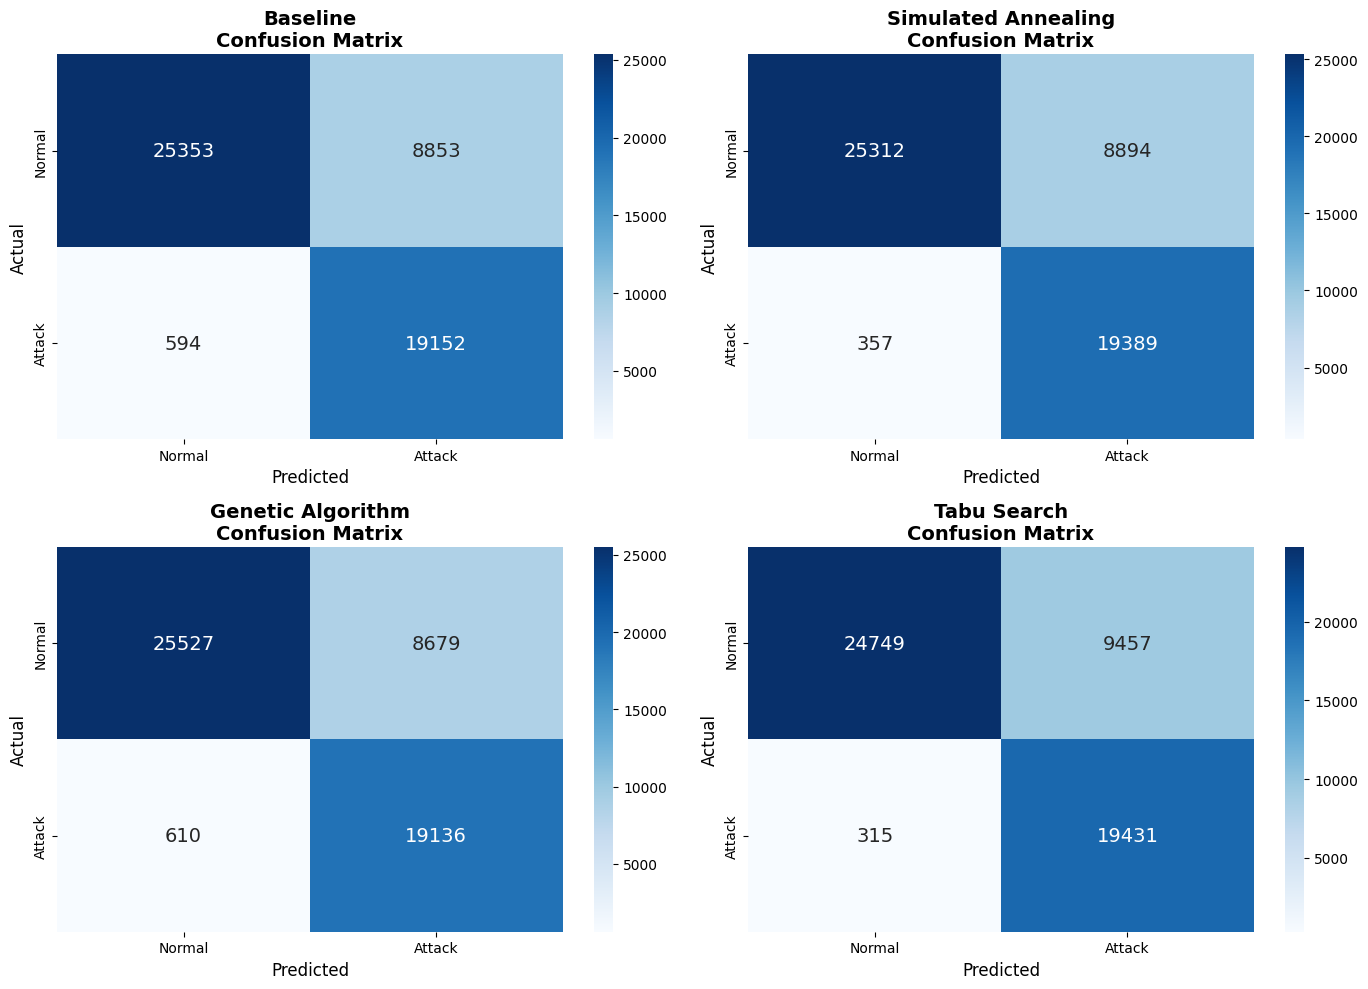

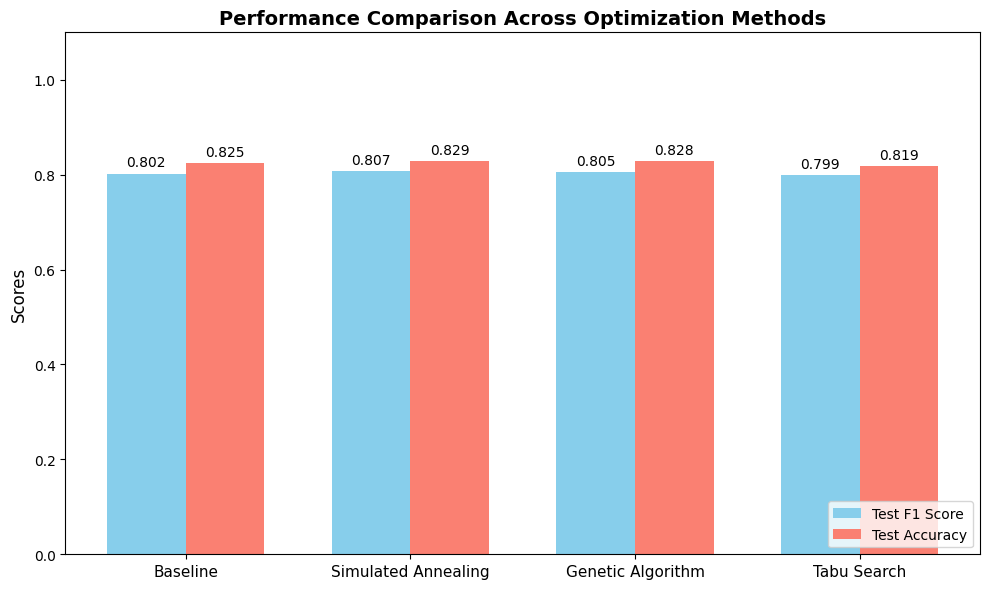

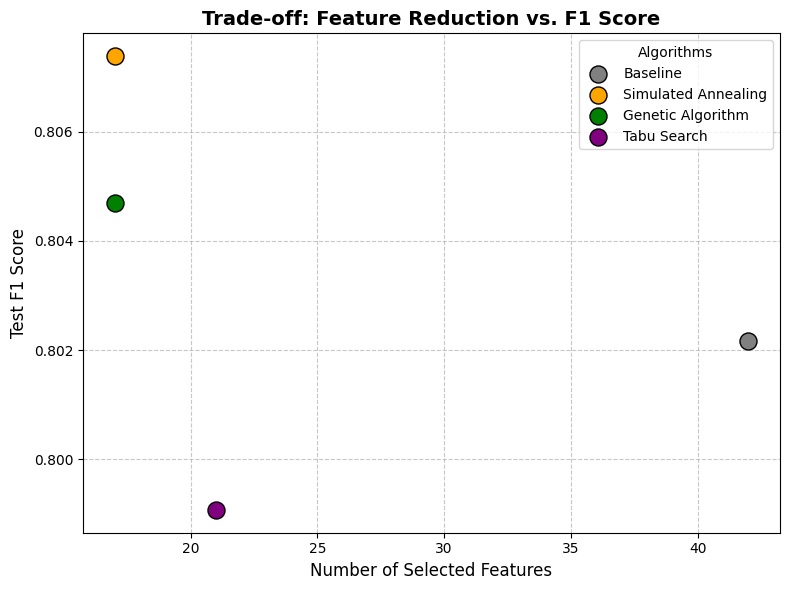

In [ ]:
# ---------------------------------------------------------
# Main pipeline
# - Load and preprocess data
# - Run metaheuristic optimization
# - Evaluate optimized models against baseline
# - Generate tables and plots
# ---------------------------------------------------------
if __name__ == "__main__":
    # Fix random seeds for reproducibility
    np.random.seed(42)   # NumPy random operations
    random.seed(42)      # Python random operations

    # -------------------------------
    # Load, clean, and encode dataset
    # -------------------------------
    train_df, test_df = load_data()
    train_df, test_df = clean_data(train_df, test_df)
    train_df, test_df = encode_data(train_df, test_df)

    # Check label distribution to understand class imbalance
    check_class_distribution(train_df, test_df)

    # ------------------------------------------------------
    # Use up to 50k samples for faster metaheuristic search
    # This reduces search time while keeping the search representative
    # ------------------------------------------------------
    sample_size = min(50000, len(train_df))

    train_df_sm, _ = train_test_split(
        train_df,
        train_size=sample_size,
        stratify=train_df['label'],
        random_state=42
    )

    # Create train/validation split for optimization stage
    X_train_sm, y_train_sm, X_val_sm, y_val_sm = split_train_val(train_df_sm)
    search_model = RFModel(X_train_sm, y_train_sm, X_val_sm, y_val_sm)

    # ------------------------------------------------------
    # Full train/validation split for final evaluation stage
    # ------------------------------------------------------
    X_train, y_train, X_val, y_val = split_train_val(train_df)

    # Separate test features and labels
    X_test = test_df.drop(columns=['label']).copy()
    y_test = test_df['label']

    # Align test columns with training columns to ensure consistency
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # -------------------------------
    # Run metaheuristic optimization methods
    # -------------------------------
    print("\n--- Running Simulated Annealing ---")
    simulated_annealing = SimulatedAnnealing(search_model)
    best_SA_params, best_SA_mask, SA_runtime = simulated_annealing.run()
    print_feature_names(best_SA_mask, train_df)

    print("\n--- Running Tabu Search ---")
    tabu_search = TabuSearch(search_model, max_iters=20)
    best_TS_params, best_TS_mask, TS_runtime = tabu_search.run()
    print_feature_names(best_TS_mask, train_df)

    print("\n--- Running Genetic Algorithm ---")
    genetic_algorithm = GeneticAlgorithm(search_model, generations=10, pop_size=10)
    best_GA_params, best_GA_mask, GA_runtime = genetic_algorithm.run()
    print_feature_names(best_GA_mask, train_df)

    # ------------------------------------------------------
    # Combine train and validation data for final model training
    # ------------------------------------------------------
    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    # -------------------------------
    # Baseline model using default Random Forest settings
    # -------------------------------
    print("\n--- Running Baseline Model ---")

    baseline_params = {}

    # Baseline uses all available features
    baseline_mask = np.ones(X_train_full.shape[1], dtype=bool)

    baseline_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    baseline_start = time.time()
    baseline_model.fit(X_train_full, y_train_full)
    baseline_runtime = time.time() - baseline_start

    print(f"Baseline training runtime: {baseline_runtime:.2f} seconds")
    print(f"Baseline selected features: {np.sum(baseline_mask)}")
    print_feature_names(baseline_mask, train_df)

    # ------------------------------------------------------
    # Store optimized parameters, feature masks, and runtimes
    # ------------------------------------------------------
    best_params_dict = {
        "Baseline": baseline_params,
        "Simulated Annealing": best_SA_params,
        "Genetic Algorithm": best_GA_params,
        "Tabu Search": best_TS_params
    }

    feature_masks_dict = {
        "Baseline": baseline_mask,
        "Simulated Annealing": best_SA_mask,
        "Genetic Algorithm": best_GA_mask,
        "Tabu Search": best_TS_mask
    }

    runtime_dict = {
        "Baseline": baseline_runtime,
        "Simulated Annealing": SA_runtime,
        "Genetic Algorithm": GA_runtime,
        "Tabu Search": TS_runtime
    }

    # -------------------------------
    # Final evaluation on full training set + official test set
    # -------------------------------
    print("\n--- Running final evaluation on all models ---")
    results = final_evaluate(
        X_train_full,
        y_train_full,
        X_test,
        y_test,
        best_params_dict,
        feature_masks_dict,
        k=5
    )

    # Print summary table of results
    print_summary_table(results, runtime_dict)

    # Generate visualizations for report and analysis
    print("\n--- Generating Confusion Matrix and Plots ---")
    plot_all_confusion_matrices(results)
    plot_performance_comparison(results)
    plot_tradeoff_analysis(results)

In [1]:
!python --version

Python 3.12.13
